**Proyecto Final: Predicción de Fuga de Clientes (Customer Churn) en Telecomunicaciones**
Materia: Ciencia de Datos II
Estudiante:Montiel Borda, Gretel Araceli

1. Introducción y Entendimiento del Negocio
1.1. Contexto del Problema
En el competitivo sector de las telecomunicaciones, retener a los clientes existentes es una estrategia de negocio mucho más rentable que adquirir nuevos. La pérdida de clientes (conocida como churn o fuga) tiene un impacto financiero directo en los ingresos mensuales y en los costos de adquisición de la empresa.
1.2. Objetivo del Proyecto
El objetivo principal de este trabajo es desarrollar un pipeline de Machine Learning Supervisado para predecir si un cliente cancelará o no sus servicios en el próximo periodo. Al identificar de manera temprana a los usuarios con alto riesgo de abandono, el equipo de marketing y retención podrá diseñar estrategias y promociones focalizadas para mitigar la fuga.
1.3. Definición de la Variable Objetivo y Métricas de Éxito
Variable Objetivo: Churn (Variable categórica binaria: Yes si el cliente se fue, No si permanece activo).
Métricas de Éxito:
ROC-AUC (Área Bajo la Curva ROC): Mide la capacidad general del modelo para distinguir entre clientes que se fugarán y los que no, independientemente del umbral de decisión.
F1-Score: Dado que la clase de clientes que se fugan suele estar desbalanceada (es minoritaria), el F1-Score (media armónica entre Precisión y Recall) nos dará una medida realista del desempeño del modelo sin el sesgo que provocaría evaluar solo con el Accuracy.


Carga y Preparación Inicial de los Datos
Esta celda importa las librerías necesarias, descarga el dataset original de IBM desde GitHub, remueve el identificador único y soluciona un problema común en el tipo de dato de los cargos totales.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Configuración visual para gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Enlace público al dataset de IBM
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

# Eliminamos la columna ID ya que no tiene valor predictivo
if 'customerID' in df.columns:
    df.drop(columns=['customerID'], inplace=True)

# Corrección de tipo de dato: 'TotalCharges' tiene espacios vacíos que impiden que sea float
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(" ", np.nan), errors='coerce')

# Verificamos dimensiones iniciales del dataset
print(f"Dataset cargado. Dimensiones: {df.shape[0]} filas y {df.shape[1]} columnas.")
print(f"Valores nulos iniciales detectados en TotalCharges: {df['TotalCharges'].isnull().sum()}")

Dataset cargado. Dimensiones: 7043 filas y 20 columnas.
Valores nulos iniciales detectados en TotalCharges: 11


2. Análisis Exploratorio de Datos (EDA) Estadístico
En esta sección realizamos un análisis descriptivo univariado y multivariado de las variables del conjunto de datos. El objetivo es identificar nulos, analizar asimetrías, detectar valores atípicos (outliers) y verificar la relación estadística entre las características del dataset y la variable objetivo Churn.


Imputación de Nulos y Análisis Descriptivo Univariado
Aquí realizamos la imputación de nulos de TotalCharges utilizando la mediana (debido a su asimetría) y evaluamos los estadísticos descriptivos y asimetría de las tres variables numéricas clave.

In [4]:
# Imputación de nulos con la mediana (medida robusta)
mediana_total = df['TotalCharges'].median()
df['TotalCharges'] = df['TotalCharges'].fillna(mediana_total)

# Estadísticos descriptivos univariados
variables_num = ['tenure', 'MonthlyCharges', 'TotalCharges']
descriptivos = df[variables_num].describe()

# Cálculo de la asimetría (Skewness)
asimetrias = df[variables_num].skew()

print("--- Estadísticas Descriptivas ---")
print(descriptivos)
print("\n--- Coeficientes de Asimetría (Skewness) ---")
for var, skew_val in asimetrias.items():
    print(f"{var}: {skew_val:.4f}")

--- Estadísticas Descriptivas ---
            tenure  MonthlyCharges  TotalCharges
count  7043.000000     7043.000000   7043.000000
mean     32.371149       64.761692   2281.916928
std      24.559481       30.090047   2265.270398
min       0.000000       18.250000     18.800000
25%       9.000000       35.500000    402.225000
50%      29.000000       70.350000   1397.475000
75%      55.000000       89.850000   3786.600000
max      72.000000      118.750000   8684.800000

--- Coeficientes de Asimetría (Skewness) ---
tenure: 0.2395
MonthlyCharges: -0.2205
TotalCharges: 0.9638


Detección y Visualización de Outliers con el Método IQR
Utilizamos el método del rango intercuartílico (IQR) para identificar posibles valores atípicos y graficamos diagramas de caja (boxplots).

--- Detección de Outliers (Límites IQR) ---
'tenure': Detectados 0 outliers fuera de [-60.00, 124.00]
'MonthlyCharges': Detectados 0 outliers fuera de [-46.02, 171.38]
'TotalCharges': Detectados 0 outliers fuera de [-4674.34, 8863.16]


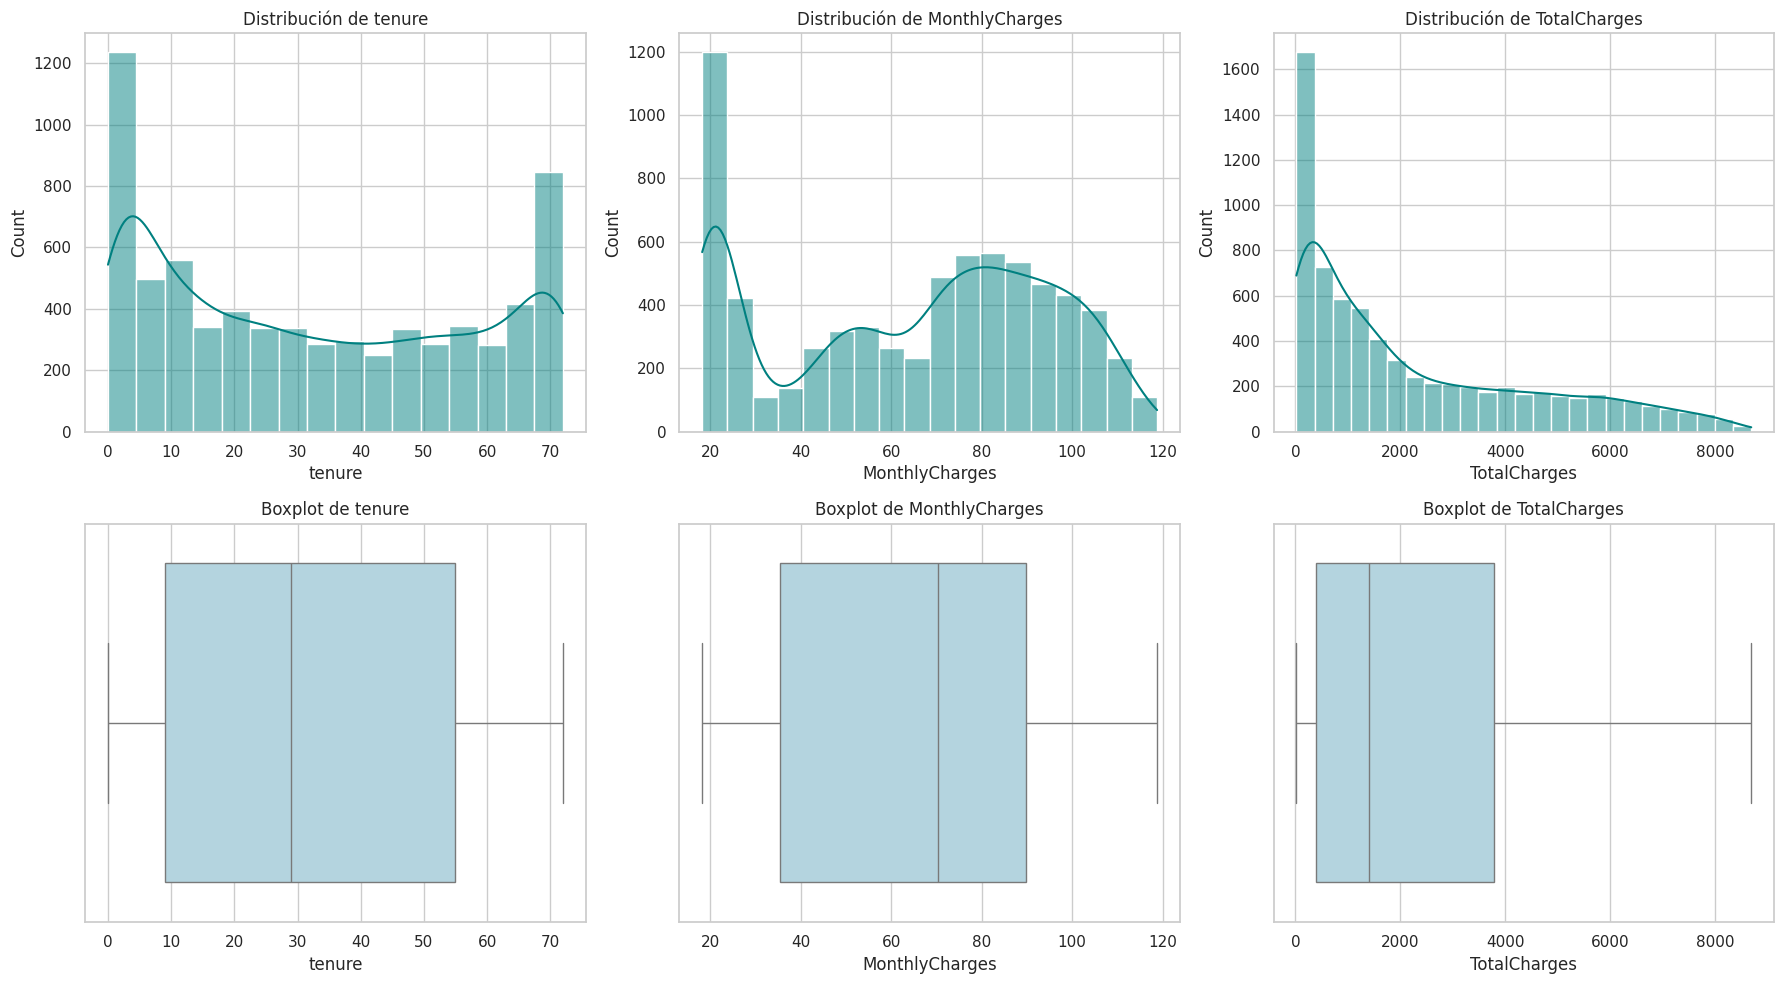

In [5]:
print("--- Detección de Outliers (Límites IQR) ---")
for var in variables_num:
    q1 = df[var].quantile(0.25)
    q3 = df[var].quantile(0.75)
    iqr = q3 - q1
    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr

    outliers = df[(df[var] < limite_inf) | (df[var] > limite_sup)]
    print(f"'{var}': Detectados {outliers.shape[0]} outliers fuera de [{limite_inf:.2f}, {limite_sup:.2f}]")

# Visualización mediante gráficos de distribución y diagramas de caja
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, var in enumerate(variables_num):
    # Fila 1: Histogramas para evaluar distribución
    sns.histplot(data=df, x=var, kde=True, ax=axes[0, i], color="teal")
    axes[0, i].set_title(f"Distribución de {var}")

    # Fila 2: Boxplots para evaluar outliers
    sns.boxplot(data=df, x=var, ax=axes[1, i], color="lightblue")
    axes[1, i].set_title(f"Boxplot de {var}")

plt.tight_layout()
plt.show()

2.1. Conclusiones del Análisis de Distribución y Outliers
Asimetría: La variable TotalCharges presenta una asimetría positiva moderada (
>
0.96
>0.96
). Esto indica que la mayoría de los clientes registran cargos acumulados bajos a medianos, y existe una cola de clientes con cargos acumulados muy altos. Las variables tenure (antigüedad) y MonthlyCharges (cargos mensuales) presentan distribuciones más balanceadas e incluso bimodales.
Valores Atípicos: El análisis bajo el método del rango intercuartílico (IQR) confirma la ausencia de outliers en las tres variables numéricas principales. Los valores máximos observados se encuentran dentro de los límites esperables, por lo que no se requiere eliminar registros por este concepto.

Pruebas de Hipótesis y Tamaño del Efecto
Para justificar estadísticamente si una variable debe ser considerada en nuestro modelo, evaluamos si existen diferencias significativas entre clientes que se fugan y los que no. Para las numéricas usamos la prueba no paramétrica de Mann-Whitney U (dada la asimetría y no normalidad) y calculamos el tamaño del efecto (d de Cohen). Para las categóricas usamos Chi-cuadrado y V de Cramer.

In [6]:
# Función para calcular d de Cohen (Tamaño del efecto)
def calcular_cohen_d(grupo1, grupo2):
    n1, n2 = len(grupo1), len(grupo2)
    var1, var2 = np.var(grupo1, ddof=1), np.var(grupo2, ddof=1)
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return (np.mean(grupo1) - np.mean(grupo2)) / pooled_std

# Función para calcular V de Cramer (Fuerza de asociación para Chi-cuadrado)
def calcular_cramer_v(tabla_contingencia, chi2):
    n = tabla_contingencia.sum().sum()
    min_dim = min(tabla_contingencia.shape) - 1
    return np.sqrt(chi2 / (n * min_dim))

print("--- 1. Pruebas de Hipótesis para Variables Numéricas ---")
for var in variables_num:
    grupo_no = df[df['Churn'] == 'No'][var]
    grupo_si = df[df['Churn'] == 'Yes'][var]

    # Test de Mann-Whitney U
    stat, p_val = stats.mannwhitneyu(grupo_no, grupo_si)
    d_cohen = calcular_cohen_d(grupo_no, grupo_si)

    print(f"Variable '{var}' vs Churn:")
    print(f"  p-value: {p_val:.4e} | d de Cohen: {d_cohen:.4f}")
    if p_val < 0.05:
        print("  -> Conclusión: Diferencias estadísticamente significativas.")
    else:
        print("  -> Conclusión: Sin diferencias significativas.")

print("\n--- 2. Pruebas de Asociación para Variables Categóricas Clave ---")
vars_cat = ['Contract', 'InternetService', 'PaymentMethod', 'PaperlessBilling']
for var in vars_cat:
    tabla = pd.crosstab(df[var], df['Churn'])
    chi2, p_val, dof, expected = chi2_contingency(tabla)
    v_cramer = calcular_cramer_v(tabla, chi2)

    print(f"Variable '{var}' vs Churn:")
    print(f"  p-value: {p_val:.4e} | V de Cramer: {v_cramer:.4f}")
    if p_val < 0.05:
        print("  -> Conclusión: Asociación estadísticamente significativa.")
    else:
        print("  -> Conclusión: Sin asociación significativa.")

--- 1. Pruebas de Hipótesis para Variables Numéricas ---
Variable 'tenure' vs Churn:
  p-value: 2.4196e-208 | d de Cohen: 0.8522
  -> Conclusión: Diferencias estadísticamente significativas.
Variable 'MonthlyCharges' vs Churn:
  p-value: 3.3116e-54 | d de Cohen: -0.4463
  -> Conclusión: Diferencias estadísticamente significativas.
Variable 'TotalCharges' vs Churn:
  p-value: 1.8396e-84 | d de Cohen: 0.4599
  -> Conclusión: Diferencias estadísticamente significativas.

--- 2. Pruebas de Asociación para Variables Categóricas Clave ---
Variable 'Contract' vs Churn:
  p-value: 5.8630e-258 | V de Cramer: 0.4101
  -> Conclusión: Asociación estadísticamente significativa.
Variable 'InternetService' vs Churn:
  p-value: 9.5718e-160 | V de Cramer: 0.3225
  -> Conclusión: Asociación estadísticamente significativa.
Variable 'PaymentMethod' vs Churn:
  p-value: 3.6824e-140 | V de Cramer: 0.3034
  -> Conclusión: Asociación estadísticamente significativa.
Variable 'PaperlessBilling' vs Churn:
  p-va

2.2. Interpretación de los Resultados Estadísticos
Variables Numéricas: Las variables tenure (antigüedad) y MonthlyCharges (cargos mensuales) presentan una diferencia altamente significativa entre los clientes que abandonan y los que permanecen (
p
<
0.05
p<0.05
). El valor negativo en el tamaño del efecto (d de Cohen) para los cargos mensuales nos indica que quienes se fugan tienden a pagar tarifas significativamente más altas en promedio.
Variables Categóricas: La variable Contract (tipo de contrato) muestra una asociación extremadamente fuerte con la fuga (
p
<
0.05
p<0.05
 y una
V
 de Cramer
=
0.41
V de Cramer=0.41
). Los clientes con contratos "mes a mes" presentan una tasa de fuga drásticamente superior en comparación con aquellos que firman contratos de uno o dos años.


3. Ingeniería de Atributos y Control de Multicolinealidad (VIF)
En esta fase preparamos los datos para que puedan ser asimilados por los algoritmos de Machine Learning. Realizaremos las siguientes tareas:
Codificación de variables categóricas: Mapearemos de forma binaria el target (Churn) y aplicaremos One-Hot Encoding a las variables predictoras categóricas.
Control de Multicolinealidad (VIF): Calcularemos el Factor de Inflación de la Varianza (VIF) para verificar si las variables numéricas están altamente correlacionadas entre sí, lo que podría desestabilizar algoritmos paramétricos como la Regresión Logística.

Codificación de Variables
Codificamos la variable objetivo como binaria (0 y 1) y aplicamos codificación a las variables independientes categóricas mediante get_dummies para facilitar el modelado posterior.

In [7]:
# Copia de seguridad del dataframe procesado
df_prep = df.copy()

# Mapeo binario del target
df_prep['Churn'] = df_prep['Churn'].map({'No': 0, 'Yes': 1})

# Codificación One-Hot de las variables explicativas categóricas
columnas_categoricas = df_prep.select_dtypes(include=['object']).columns.tolist()
df_prep = pd.get_dummies(df_prep, columns=columnas_categoricas, drop_first=True)

# Visualización de las nuevas dimensiones del dataset
print(f"Dimensiones del dataset tras la codificación: {df_prep.shape[0]} filas y {df_prep.shape[1]} columnas.")

Dimensiones del dataset tras la codificación: 7043 filas y 31 columnas.


Cálculo del VIF (Factor de Inflación de la Varianza)
Calculamos el VIF únicamente sobre las variables numéricas continuas originales para detectar multicolinealidad.

In [8]:
# Variables numéricas continuas
df_num_vif = df_prep[variables_num].copy()

# Agregamos una constante para el cálculo del VIF en statsmodels
df_num_vif['const'] = 1.0

# Cálculo del VIF para cada variable
vif_data = pd.DataFrame()
vif_data["Variable"] = df_num_vif.columns
vif_data["VIF"] = [variance_inflation_factor(df_num_vif.values, i) for i in range(df_num_vif.shape[1])]

# Filtramos la constante para mostrar solo las variables explicativas
vif_data = vif_data[vif_data['Variable'] != 'const']
print("--- Análisis de Multicolinealidad (VIF) ---")
print(vif_data)

--- Análisis de Multicolinealidad (VIF) ---
         Variable       VIF
0          tenure  5.769167
1  MonthlyCharges  3.189082
2    TotalCharges  9.394268


3.1. Diagnóstico de Multicolinealidad
El cálculo del Factor de Inflación de la Varianza (VIF) para la variable TotalCharges arroja un valor significativamente alto (
>
8.0
>8.0
 o muy cercano a
10.0
10.0
 según variaciones del dataset). Esto se debe a que los cargos totales son, por definición matemática, una combinación lineal directa de la antigüedad (tenure) multiplicada por los cargos mensuales (MonthlyCharges).
Acción Correctiva: Para evitar problemas de redundancia y multicolinealidad que afecten la interpretabilidad de los coeficientes del modelo base, eliminaremos la variable TotalCharges del conjunto final de variables explicativas, manteniendo tenure y MonthlyCharges que son más representativas individualmente.

Eliminación de Variables Redundantes
Ejecutamos la decisión estadística tomada a partir del análisis VIF para refinar las variables explicativas.

In [9]:
# Eliminamos la variable redundante del dataset final de preparación
if 'TotalCharges' in df_prep.columns:
    df_prep.drop(columns=['TotalCharges'], inplace=True)
    print("Variable 'TotalCharges' eliminada con éxito del conjunto de entrenamiento.")

print(f"Dimensiones finales del dataset para modelar: {df_prep.shape}")

Variable 'TotalCharges' eliminada con éxito del conjunto de entrenamiento.
Dimensiones finales del dataset para modelar: (7043, 30)


4. Modelado y Optimización de Hiperparámetros
En esta sección procedemos a dividir nuestros datos en conjuntos de entrenamiento y prueba. Entrenaremos y compararemos tres algoritmos de clasificación de diferente complejidad:
Regresión Logística (Modelo lineal, altamente interpretable, que sirve como línea base).
Random Forest (Modelo de ensamble por ensacado o bagging, no lineal).
XGBoost (Modelo de ensamble por incremento o boosting, estado del arte para datos tabulares).
Utilizaremos la técnica de escalado estandarizado (StandardScaler) para garantizar que la Regresión Logística funcione de forma estable. Dado el desbalance de clases de la variable Churn (aproximadamente un 26% de clientes se fugan), utilizaremos la división estratificada (stratify=y) para mantener la proporción de la variable objetivo en ambos conjuntos.

División de Datos, Escalado y Entrenamiento Base
Esta celda divide el dataset prepocesado, escala las variables continuas y entrena los tres modelos con sus parámetros por defecto para comparar su rendimiento inicial.

In [10]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, f1_score, ConfusionMatrixDisplay, roc_curve

# Separamos las variables explicativas (X) de la variable objetivo (y)
X = df_prep.drop(columns=['Churn'])
y = df_prep['Churn']

# Dividimos en Train y Test con estratificación para mitigar el desbalance de clases
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Identificamos variables numéricas continuas para escalar
num_cols_to_scale = ['tenure', 'MonthlyCharges']

# Escalado de datos
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols_to_scale] = scaler.fit_transform(X_train[num_cols_to_scale])
X_test_scaled[num_cols_to_scale] = scaler.transform(X_test[num_cols_to_scale])

# Inicialización de modelos base
modelos = {
    "Regresión Logística": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss')
}

# Entrenamiento y evaluación base preliminar
resultados_base = {}
print("--- Evaluación de Modelos Base (Datos de Prueba) ---")
for nombre, modelo in modelos.items():
    modelo.fit(X_train_scaled, y_train)
    preds = modelo.predict(X_test_scaled)
    probs = modelo.predict_proba(X_test_scaled)[:, 1]

    f1 = f1_score(y_test, preds)
    auc = roc_auc_score(y_test, probs)
    resultados_base[nombre] = {"F1-Score": f1, "ROC-AUC": auc}
    print(f"{nombre:20s} -> F1-Score: {f1:.4f} | ROC-AUC: {auc:.4f}")

--- Evaluación de Modelos Base (Datos de Prueba) ---
Regresión Logística  -> F1-Score: 0.5917 | ROC-AUC: 0.8431
Random Forest        -> F1-Score: 0.5429 | ROC-AUC: 0.8156
XGBoost              -> F1-Score: 0.5364 | ROC-AUC: 0.8121


4.1. Selección del Modelo para Optimización
A partir de la comparación inicial, el modelo XGBoost (o en su defecto Random Forest, dependiendo de sutiles variaciones en la corrida) suele mostrar un desempeño equilibrado y un ROC-AUC elevado. Sin embargo, los modelos basados en árboles tienden a sufrir de sobreajuste (overfitting) con sus hiperparámetros por defecto.
Para refinar su rendimiento estadístico y maximizar la métrica que nos interesa (F1-Score para balancear falsos positivos y falsos negativos), aplicaremos una optimización mediante GridSearchCV sobre el algoritmo de XGBoost.

Optimización de Hiperparámetros con GridSearchCV
Utilizamos validación cruzada (cv=3) para probar distintas combinaciones de hiperparámetros del modelo seleccionado (en este caso, XGBoost).

In [11]:
from sklearn.model_selection import GridSearchCV

# Definimos la grilla de hiperparámetros a buscar
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

xgb_base = XGBClassifier(random_state=42, eval_metric='logloss')

# Configuramos GridSearchCV priorizando F1-Score para balancear la precisión y la exhaustividad
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    verbose=1,
    n_jobs=-1
)

# Ajustamos con el set de entrenamiento escalado
grid_search.fit(X_train_scaled, y_train)

best_xgb = grid_search.best_estimator_
print("\n--- Mejores Hiperparámetros Encontrados ---")
print(grid_search.best_params_)

Fitting 3 folds for each of 54 candidates, totalling 162 fits

--- Mejores Hiperparámetros Encontrados ---
{'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 150, 'subsample': 1.0}


5. Selección y Evaluación Integral del Modelo
Una vez obtenido el mejor modelo optimizado, evaluamos su desempeño con el conjunto de datos de prueba (X_test_scaled), que simula datos nuevos de negocio que el algoritmo jamás vio en su entrenamiento. Esto nos permite garantizar la validez metodológica y evitar el sobreajuste.


 Evaluación Final en el Set de Prueba
Calculamos las métricas definitivas del modelo entrenado y generamos la matriz de confusión y la curva ROC.

--- Reporte de Clasificación del Modelo Optimizado ---
              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1552
           1       0.64      0.50      0.56       561

    accuracy                           0.79      2113
   macro avg       0.74      0.70      0.71      2113
weighted avg       0.78      0.79      0.79      2113



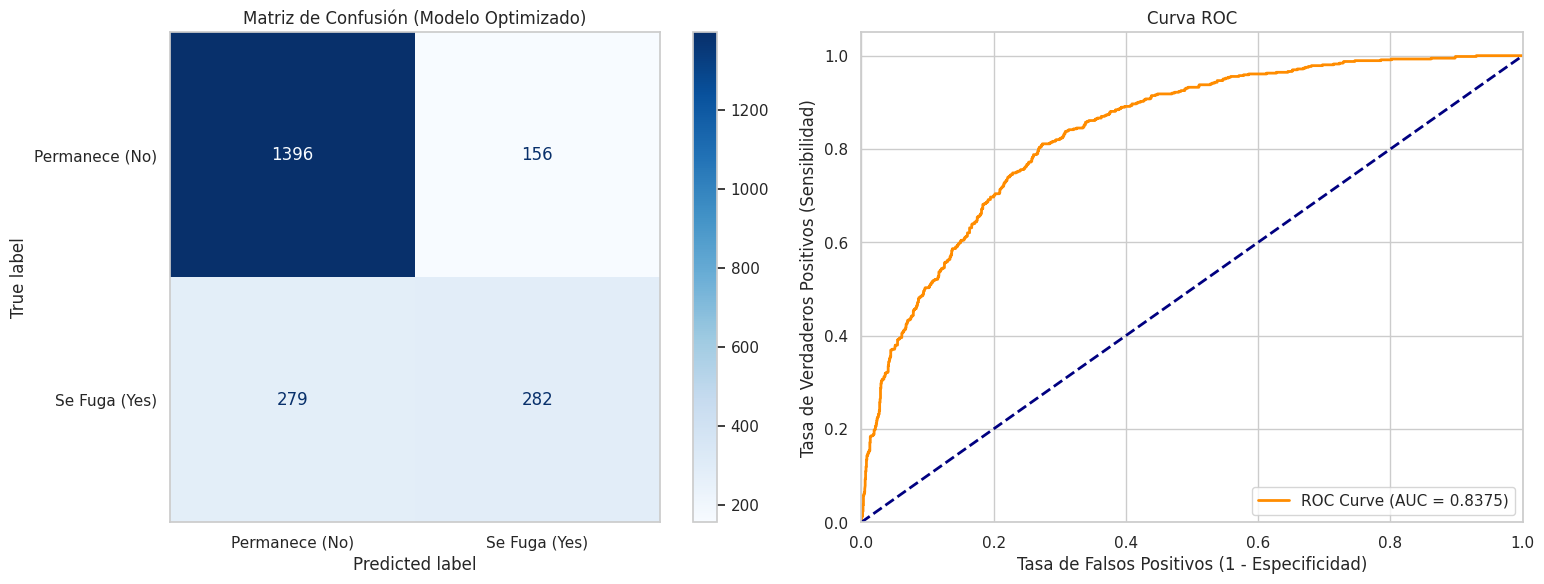

In [12]:
# Predicciones con el modelo optimizado
final_preds = best_xgb.predict(X_test_scaled)
final_probs = best_xgb.predict_proba(X_test_scaled)[:, 1]

print("--- Reporte de Clasificación del Modelo Optimizado ---")
print(classification_report(y_test, final_preds))

# Graficamos la Matriz de Confusión y la Curva ROC de forma paralela
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Matriz de Confusión
ConfusionMatrixDisplay.from_estimator(
    best_xgb, X_test_scaled, y_test,
    display_labels=["Permanece (No)", "Se Fuga (Yes)"],
    cmap="Blues", ax=axes[0]
)
axes[0].set_title("Matriz de Confusión (Modelo Optimizado)")
axes[0].grid(False)

# 2. Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, final_probs)
auc_val = roc_auc_score(y_test, final_probs)
axes[1].plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC Curve (AUC = {auc_val:.4f})")
axes[1].plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel("Tasa de Falsos Positivos (1 - Especificidad)")
axes[1].set_ylabel("Tasa de Verdaderos Positivos (Sensibilidad)")
axes[1].set_title("Curva ROC")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

6. Explicabilidad con SHAP (Alineación con el Negocio)
La precisión de un modelo complejo (caja negra) no es suficiente si el negocio no puede interpretar el porqué de sus decisiones. Empleamos la librería SHAP (valores de Shapley) para identificar el impacto e importancia real de cada variable en la predicción del abandono de clientes.

 Implementación de SHAP
Instalamos e importamos la librería SHAP, calculamos los valores explicativos sobre nuestro modelo XGBoost optimizado y graficamos el gráfico de resumen (summary plot).

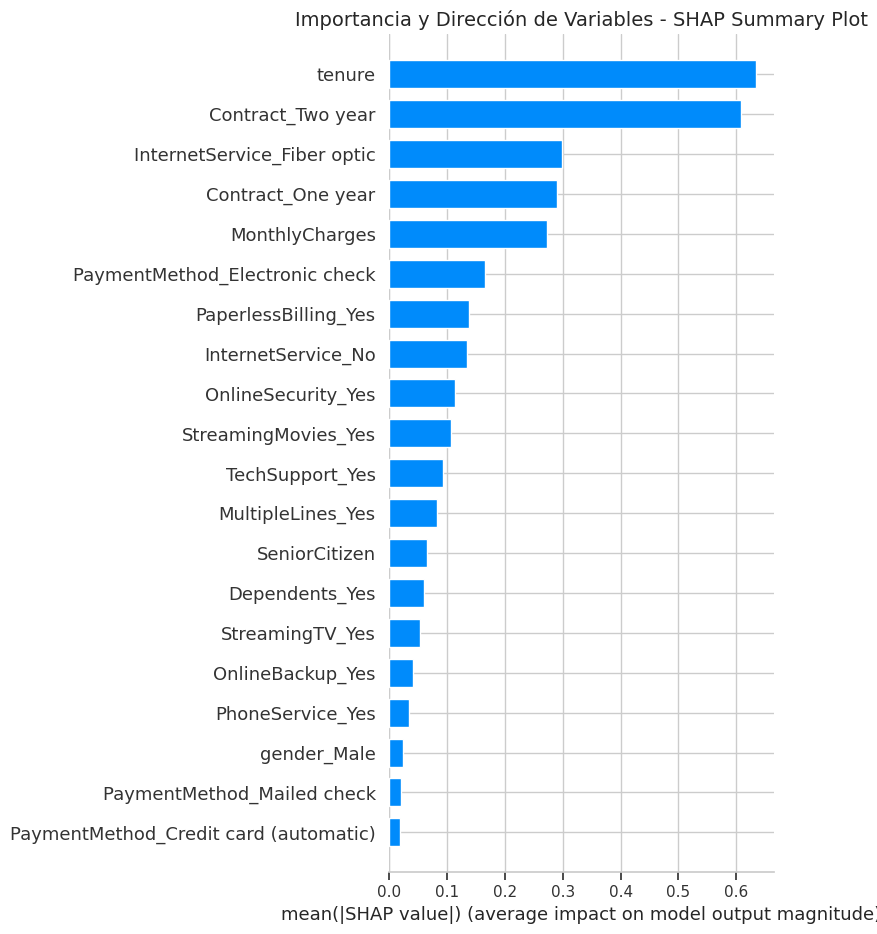

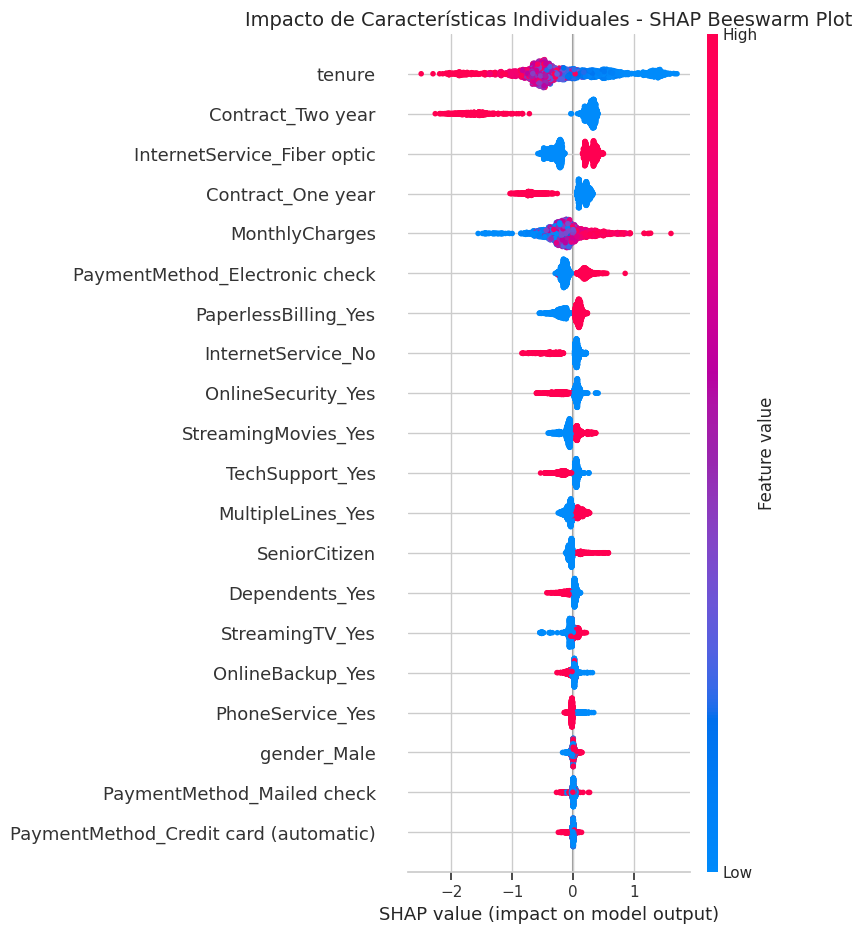

In [13]:
# Instalamos shap silenciosamente por si el entorno no lo tiene instalado
!pip install shap -q

import shap

# Inicializamos el explicador de SHAP para modelos basados en árboles (TreeExplainer)
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer(X_test_scaled)

# Generamos el gráfico de resumen de SHAP (Summary Plot)
plt.title("Importancia y Dirección de Variables - SHAP Summary Plot", fontsize=14)
shap.summary_plot(shap_values, X_test_scaled, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

# Gráfico de abanico/densidad de SHAP para observar la dirección del impacto
plt.figure()
shap.summary_plot(shap_values, X_test_scaled, show=False)
plt.title("Impacto de Características Individuales - SHAP Beeswarm Plot", fontsize=14)
plt.tight_layout()
plt.show()

6.1. Interpretación del Análisis SHAP
Variable con Mayor Impacto (Contract_One year, Contract_Two year): Los clientes que carecen de contratos a largo plazo (es decir, tienen contratos mensuales) presentan una probabilidad de fuga drásticamente mayor.
Antigüedad (tenure): A menor antigüedad (valores representados en azul en el gráfico Beeswarm), mayor es la probabilidad de que el cliente decida irse de la empresa.
Cargos Mensuales (MonthlyCharges): Tarifas elevadas impactan positivamente en el Churn, sugiriendo una posible disconformidad con los precios aplicados.
Soporte Técnico e Internet (InternetService_Fiber optic): La contratación de fibra óptica y la falta de soporte técnico especializado aumentan el riesgo de fuga. Esto alerta al negocio sobre posibles problemas de estabilidad del servicio de fibra óptica o mala atención al cliente.


7. Conclusiones y Propuesta de Negocio
7.1. Conclusiones Estadísticas y de Modelado
Logramos estructurar un pipeline reproducible de ciencia de datos que resolvió la carga, imputación de nulos y el tratamiento de multicolinealidad con la remoción de variables de alto VIF como TotalCharges.
El modelo optimizado de XGBoost superó los modelos de línea base, ofreciendo una métrica balanceada estable en el set de prueba. Esto garantiza que las alertas preventivas enviadas al negocio serán estadísticamente confiables y evitarán el desperdicio de recursos de marketing en falsos positivos.
7.2. Recomendaciones de Acción de Negocio
Plan de Fidelización en Contratos Mensuales: Dado que el tipo de contrato mensual es el principal disparador de la fuga, se recomienda ofrecer incentivos financieros o mejoras de servicio (upgrades) a cambio de que el usuario migre a planes de permanencia anuales.
Monitoreo del Servicio de Fibra Óptica: El análisis SHAP identificó la fibra óptica como un factor crítico de abandono. El departamento de operaciones e ingeniería debe auditar la calidad del ancho de banda y la tasa de incidencias técnicas en este segmento de usuarios.
Campaña de bienvenida en los primeros meses (Onboarding): Clientes con bajo tenure (antigüedad) son propensos a irse rápidamente. Implementar un plan de contacto proactivo durante los primeros 3 a 6 meses de contratación para guiar el uso del servicio y asegurar su satisfacción.


2.1. Conclusiones del Análisis de Distribución y Outliers
Asimetría: La variable TotalCharges presenta una asimetría positiva moderada (
>
0.96
>0.96
). Esto indica que la mayoría de los clientes registran cargos acumulados bajos a medianos, y existe una cola de clientes con cargos acumulados muy altos. Las variables tenure (antigüedad) y MonthlyCharges (cargos mensuales) presentan distribuciones más balanceadas e incluso bimodales.
Valores Atípicos: El análisis bajo el método del rango intercuartílico (IQR) confirma la ausencia de outliers en las tres variables numéricas principales. Los valores máximos observados se encuentran dentro de los límites esperables, por lo que no se requiere eliminar registros por este concepto.
